In [1]:
# Import required libraries for file handling and visualization
import os
import matplotlib.pyplot as plt
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from PIL import Image
import random
import seaborn as sns



In [2]:
# PyTorch Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models



In [3]:
# Setup device for CUDA support
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================


Using device: cpu


In [4]:
# 1. Path Setup & Exploration
# ==========================================
base_path = "D:/RHJ/DataSet/Raabin WBC"
train_path = os.path.join(base_path, 'Train')
test_path = os.path.join(base_path, 'Test')

print("base_path =", os.path.abspath(base_path))
print("train_path =", os.path.abspath(train_path))
print("test_path =", os.path.abspath(test_path))

print("Train classes:", os.listdir(train_path))
print("Test classes:", os.listdir(test_path))



base_path = D:\RHJ\DataSet\Raabin WBC
train_path = D:\RHJ\DataSet\Raabin WBC\Train
test_path = D:\RHJ\DataSet\Raabin WBC\Test
Train classes: ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']
Test classes: ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']


In [5]:
import os
import hashlib

def get_hash(file_path):
    with open(file_path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

train_hashes = set()
test_hashes = set()

# Train
for cls in os.listdir(train_path):
    class_path = os.path.join(train_path, cls)
    for img in os.listdir(class_path):
        path = os.path.join(class_path, img)
        train_hashes.add(get_hash(path))

# Test
for cls in os.listdir(test_path):
    class_path = os.path.join(test_path, cls)
    for img in os.listdir(class_path):
        path = os.path.join(class_path, img)
        test_hashes.add(get_hash(path))

duplicates = train_hashes.intersection(test_hashes)

print("عدد الصور المكررة فعليًا:", len(duplicates))

عدد الصور المكررة فعليًا: 0


In [6]:
# Base transform to mimic Keras image_dataset_from_directory (loads and resizes)
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()  # Automatically scales images to [0, 1]
])



In [7]:
# PyTorch Datasets for initial inspection
train_dataset = datasets.ImageFolder(train_path, transform=base_transform)
val_dataset = datasets.ImageFolder(test_path, transform=base_transform)

train_loader_initial = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader_initial = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Folders inside dataset:")
print(os.listdir(base_path))

for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)
    if os.path.isdir(folder_path):
        print(folder, "->", os.listdir(folder_path))

classes = train_dataset.classes
print("Number of classes:", len(classes))

print("\nClass names:")
for c in classes:
    print(c)



Folders inside dataset:
['Test', 'Train']
Test -> ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']
Train -> ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']
Number of classes: 5

Class names:
Basophil
Eosinophil
Lymphocyte
Monocyte
Neutrophil


In [8]:
# Count number of images in each class
class_counts = {}
for class_name in classes:
    class_path = os.path.join(train_path, class_name)
    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        class_counts[class_name] = len(images)
        print(class_name, ":", len(images), "images")

# ==========================================


Basophil : 212 images
Eosinophil : 744 images
Lymphocyte : 2427 images
Monocyte : 561 images
Neutrophil : 6231 images


In [9]:
# 2. Visualizations & HSI Preprocessing 
# ==========================================


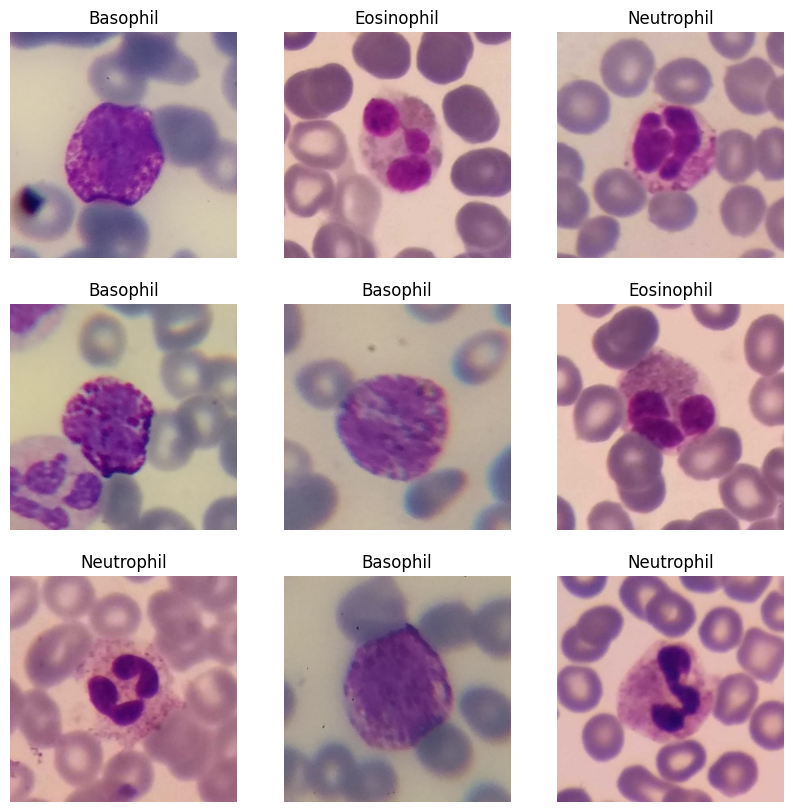

In [10]:
# Display sample images from the dataset
plt.figure(figsize=(10, 10))
for i in range(9):
    class_name = random.choice(classes)
    class_path = os.path.join(train_path, class_name)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)
    img = Image.open(img_path)
    
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")
plt.show()



In [11]:
# Check sample image sizes
image_sizes = []
for class_name in classes:
    class_path = os.path.join(train_path, class_name)
    images = os.listdir(class_path)[:5]
    for img_name in images:
        img_path = os.path.join(class_path, img_name)
        try:
            img = Image.open(img_path)
            image_sizes.append(img.size)
        except:
            pass

print("Sample image sizes:")
print(image_sizes[:10])



Sample image sizes:
[(575, 575), (575, 575), (575, 575), (575, 575), (575, 575), (575, 575), (575, 575), (575, 575), (575, 575), (575, 575)]


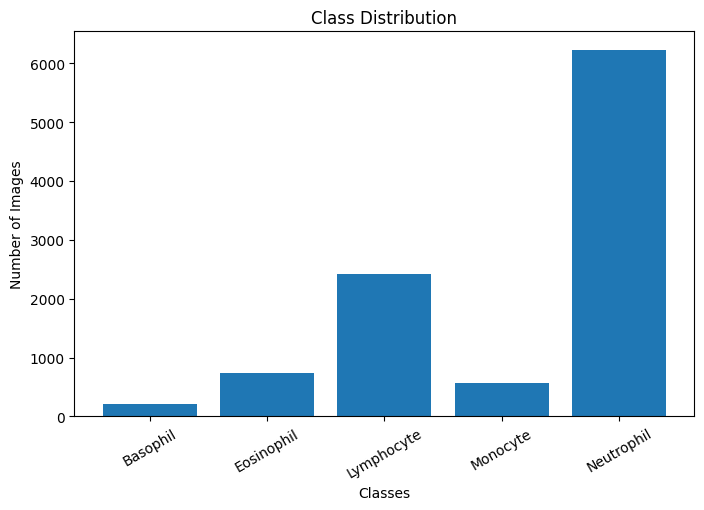

In [12]:
# Plot dataset class distribution
plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.show()



In [13]:
# Check for imbalance
max_count = max(class_counts.values())
min_count = min(class_counts.values())
if max_count - min_count > 0:
    print("Dataset has class imbalance")
else:
    print("Dataset is balanced")



Dataset has class imbalance


In [14]:
# Collect image paths and labels manually for splitting
image_paths = []
labels = []

for class_name in os.listdir(train_path):
    class_path = os.path.join(train_path, class_name)
    if os.path.isdir(class_path):
        for img in os.listdir(class_path):
            image_paths.append(os.path.join(class_path, img))
            labels.append(class_name)

print("Total images:", len(image_paths))



Total images: 10175


In [15]:
# Manual splitting matching your exact flow
train_imgs, temp_imgs, train_labels, temp_labels = train_test_split(
    image_paths, labels, test_size=0.30, stratify=labels, random_state=42
)
val_imgs, test_imgs, val_labels, test_labels = train_test_split(
    temp_imgs, temp_labels, test_size=0.50, stratify=temp_labels, random_state=42
)

print("Training images:", len(train_imgs))
print("Validation images:", len(val_imgs))
print("Testing images:", len(test_imgs))



Training images: 7122
Validation images: 1526
Testing images: 1527


X_train shape: (7122, 224, 224, 3)
X_val shape: (1526, 224, 224, 3)
X_test shape: (1527, 224, 224, 3)


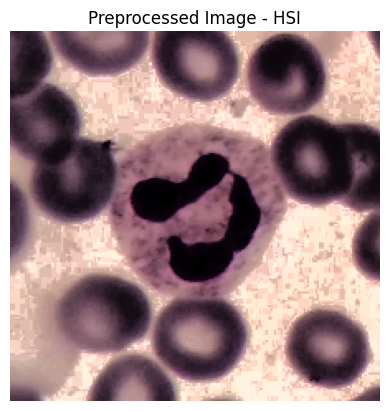

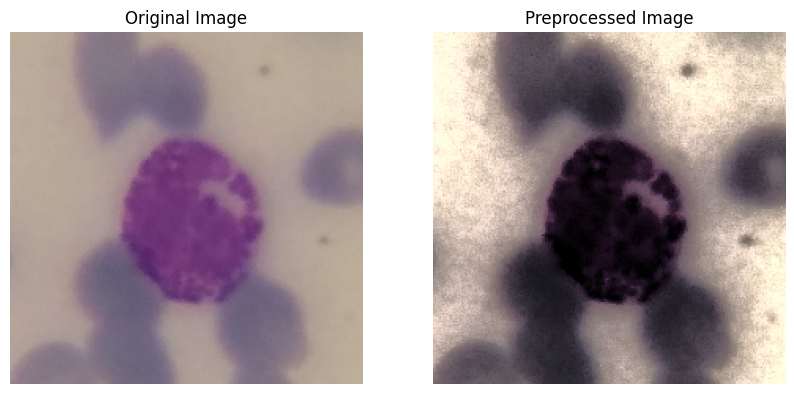

In [16]:
# HSI Logic (Kept exactly identical as it relies purely on numpy/cv2)
def rgb_to_hsi(img):
    img = img.astype(np.float32) / 255.0
    R, G, B = img[:, :, 0], img[:, :, 1], img[:, :, 2]
    I = (R + G + B) / 3.0
    min_rgb = np.minimum(np.minimum(R, G), B)
    S = np.zeros_like(I)
    denom = R + G + B
    mask = denom > 1e-8
    S[mask] = 1 - (3 * min_rgb[mask] / denom[mask])
    num = 0.5 * ((R - G) + (R - B))
    den = np.sqrt((R - G)**2 + (R - B) * (G - B)) + 1e-8
    theta = np.arccos(np.clip(num / den, -1, 1))
    H = np.zeros_like(I)
    H[B <= G] = theta[B <= G]
    H[B > G] = 2 * np.pi - theta[B > G]
    H = H / (2 * np.pi) 
    return np.stack([H, S, I], axis=-1)

def hsi_to_rgb(hsi):
    H = hsi[:, :, 0] * 2 * np.pi
    S = hsi[:, :, 1]
    I = hsi[:, :, 2]
    R, G, B = np.zeros_like(I), np.zeros_like(I), np.zeros_like(I)
    
    mask1 = (H >= 0) & (H < 2 * np.pi / 3)
    B[mask1] = I[mask1] * (1 - S[mask1])
    R[mask1] = I[mask1] * (1 + (S[mask1] * np.cos(H[mask1])) / (np.cos(np.pi / 3 - H[mask1]) + 1e-8))
    G[mask1] = 3 * I[mask1] - (R[mask1] + B[mask1])

    mask2 = (H >= 2 * np.pi / 3) & (H < 4 * np.pi / 3)
    H2 = H[mask2] - 2 * np.pi / 3
    R[mask2] = I[mask2] * (1 - S[mask2])
    G[mask2] = I[mask2] * (1 + (S[mask2] * np.cos(H2)) / (np.cos(np.pi / 3 - H2) + 1e-8))
    B[mask2] = 3 * I[mask2] - (R[mask2] + G[mask2])

    mask3 = (H >= 4 * np.pi / 3) & (H < 2 * np.pi)
    H3 = H[mask3] - 4 * np.pi / 3
    G[mask3] = I[mask3] * (1 - S[mask3])
    B[mask3] = I[mask3] * (1 + (S[mask3] * np.cos(H3)) / (np.cos(np.pi / 3 - H3) + 1e-8))
    R[mask3] = 3 * I[mask3] - (G[mask3] + B[mask3])

    rgb = np.stack([R, G, B], axis=-1)
    rgb = np.clip(rgb, 0, 1)
    return (rgb * 255).astype(np.uint8)

def preprocess_image_hsi(img_path, size=(224, 224)):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)
    hsi = rgb_to_hsi(img)
    H, S, I = hsi[:, :, 0], hsi[:, :, 1], hsi[:, :, 2]
    I_uint8 = np.clip(I * 255, 0, 255).astype(np.uint8)
    I_eq = cv2.equalizeHist(I_uint8).astype(np.float32) / 255.0
    hsi_eq = np.stack([H, S, I_eq], axis=-1)
    img_eq = hsi_to_rgb(hsi_eq)
    return img_eq.astype("float32") / 255.0

X_train = np.array([preprocess_image_hsi(p) for p in train_imgs])
X_val   = np.array([preprocess_image_hsi(p) for p in val_imgs])
X_test  = np.array([preprocess_image_hsi(p) for p in test_imgs])

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

sample = preprocess_image_hsi(train_imgs[0])
plt.imshow(sample)
plt.title("Preprocessed Image - HSI")
plt.axis("off")
plt.show()

sample_class = classes[0]
sample_image_name = os.listdir(os.path.join(train_path, sample_class))[0]
sample_image_path = os.path.join(train_path, sample_class, sample_image_name)

original = cv2.imread(sample_image_path)
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
original = cv2.resize(original, (224, 224))
processed = preprocess_image_hsi(sample_image_path)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(processed)
plt.title("Preprocessed Image")
plt.axis("off")
plt.show()

# ==========================================


In [17]:
# 3. Data Augmentation & Loaders
# ==========================================


In [18]:


# =========================
# 2. Data Augmentation (Train)
# =========================
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(36),
    transforms.RandomAffine(0, scale=(0.9, 1.1)),
    transforms.ColorJitter(contrast=0.1),
    transforms.ToTensor()
])

# =========================
# 3. Validation / Test Transform (بدون Augmentation)
# =========================
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# =========================
# 4. Datasets
# =========================
train_dataset = datasets.ImageFolder(train_path, transform=train_transform)

test_dataset = datasets.ImageFolder(test_path, transform=base_transform)

# =========================
# 5. DataLoaders
# =========================
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# =========================
# 6. Class Names
# =========================
class_names = train_dataset.classes

print("Classes:", class_names)
print("Num classes:", len(class_names))

Classes: ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']
Num classes: 5


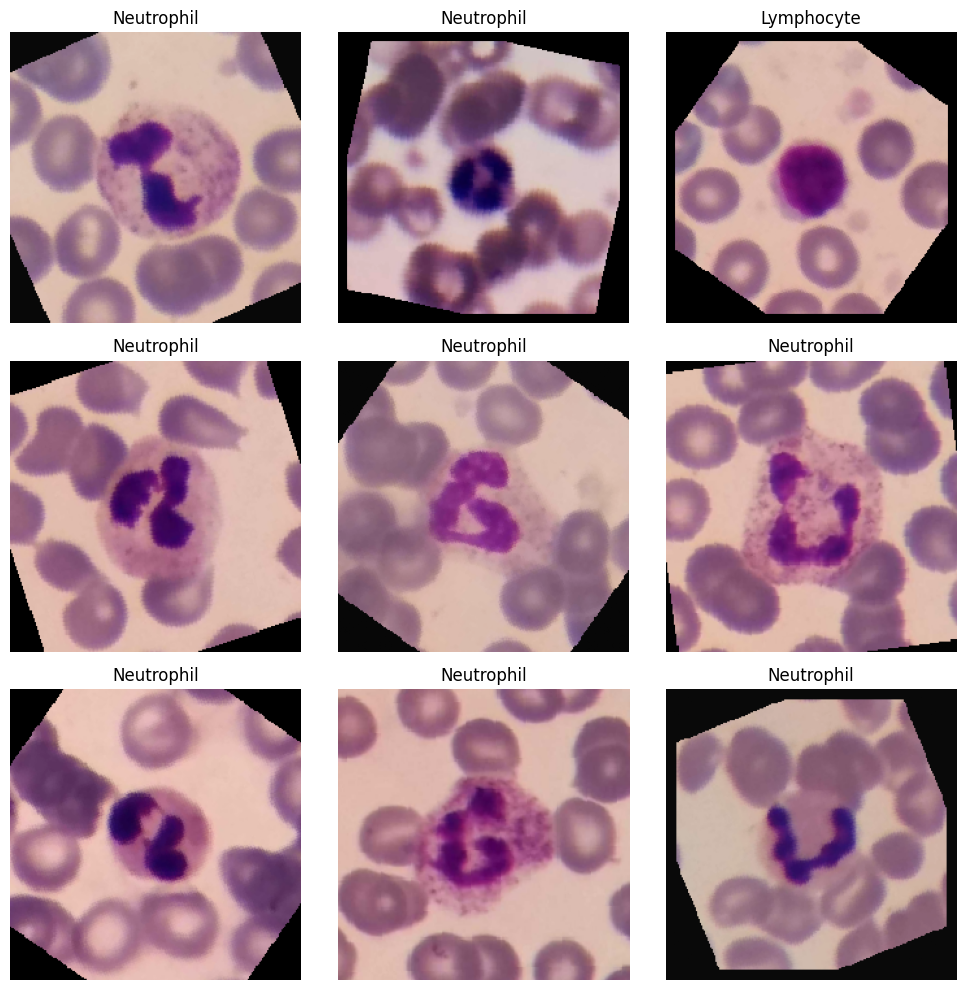

In [19]:
# Plot augmented samples
plt.figure(figsize=(10, 10))
data_iter = iter(train_loader)
images, labels = next(data_iter)

for i in range(min(9, len(images))):
    ax = plt.subplot(3, 3, i + 1)
    img = images[i].permute(1, 2, 0).numpy() # Convert from C,H,W to H,W,C
    plt.imshow(img)
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# ==========================================


In [20]:
# 4. Model Definition (Hybrid)
# ==========================================
num_classes = len(class_names)
print("Number of classes:", num_classes)
print("Class names:", class_names)

class HybridModel(nn.Module):
    def __init__(self, num_classes):
        super(HybridModel, self).__init__()
        
        # Base 1: EfficientNetV2_S
        self.eff = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1)
        eff_out_features = self.eff.classifier[1].in_features
        # EfficientNet flattens BEFORE the classifier, so replacing the whole block is fine
        self.eff.classifier = nn.Identity() 
        
        # Base 2: ConvNeXt_Tiny
        self.conv = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
        conv_out_features = self.conv.classifier[2].in_features
        # FIX: Only replace the final Linear layer (index 2). 
        # This safely preserves LayerNorm2d (index 0) and Flatten (index 1)
        self.conv.classifier[2] = nn.Identity() 
        
        # Freeze both bases initially
        for param in self.eff.parameters():
            param.requires_grad = False
        for param in self.conv.parameters():
            param.requires_grad = False
            
        # Fusion head matching TF dense layers
        self.fc1 = nn.Linear(eff_out_features + conv_out_features, 256)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, num_classes)
        
    def forward(self, x):
        # Extract features
        eff_features = self.eff(x)
        conv_features = self.conv(x)
        
        # Concatenate features (Now both are strictly 2D [batch_size, features])
        fused_features = torch.cat((eff_features, conv_features), dim=1)
        
        # Dense layers
        x = self.fc1(fused_features)
        x = self.relu(x)
        x = self.dropout(x)
        outputs = self.fc2(x)
        return outputs



Number of classes: 5
Class names: ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']


In [21]:
# Re-initialize the model to apply the fix
hybrid_model = HybridModel(num_classes).to(device)



In [22]:
# (Make sure to re-initialize the optimizer here too so it registers the new model parameters)
optimizer = optim.Adam(hybrid_model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)
criterion = nn.CrossEntropyLoss()



c:\Users\kadi9\anaconda3\envs\gp_env\lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


In [23]:
# Emulating ReduceLROnPlateau
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)



In [24]:

class HybridModel(nn.Module):
    def __init__(self, num_classes=5):
        super(HybridModel, self).__init__()

        # Backbone (EfficientNet أو أي CNN pretrained)
        self.backbone = models.efficientnet_b0(pretrained=True)

        # نشيل الطبقة الأخيرة
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()

        # Classifier جديد محسّن
        self.classifier = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),   # 🔥 مهم جدًا ضد overfitting

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.classifier(x)
        return x

In [ ]:
# Training loop abstraction to handle Keras-like epochs and history tracking

def train_eval_loop(model, train_loader, val_loader, optimizer, criterion, scheduler, epochs, save_name="best_hybrid_model.pth"):
    history = {'accuracy': [], 'loss': [], 'val_accuracy': [], 'val_loss': []}
    best_val_acc = 0.0
    patience = 3  # EarlyStopping
    trigger_times = 0

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        val_loss, v_correct, v_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs.data, 1)

                v_total += labels.size(0)
                v_correct += (predicted == labels).sum().item()

        val_loss = val_loss / v_total
        val_acc = v_correct / v_total

        history['loss'].append(train_loss)
        history['accuracy'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} - loss: {train_loss:.4f} - accuracy: {train_acc:.4f} - val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")

        scheduler.step(val_loss)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_name)
            trigger_times = 0
            print(f"--> Saved best model to {save_name}")
        else:
            trigger_times += 1
            if trigger_times >= patience:
                print("Early stopping triggered!")
                break

    model.load_state_dict(torch.load(save_name))
    return history


print("--- Starting Initial Training ---")
history_hybrid = train_eval_loop(
    hybrid_model,
    train_loader,
    val_loader_initial,   # ✅ التعديل هنا
    optimizer,
    criterion,
    scheduler,
    epochs=8
)

--- Starting Initial Training ---
Epoch 1/8 - loss: 0.2531 - accuracy: 0.9145 - val_loss: 0.2121 - val_accuracy: 0.9278
--> Saved best model to best_hybrid_model.pth
Epoch 2/8 - loss: 0.1239 - accuracy: 0.9610 - val_loss: 0.7296 - val_accuracy: 0.7691
Epoch 3/8 - loss: 0.1008 - accuracy: 0.9682 - val_loss: 0.3253 - val_accuracy: 0.9009


In [31]:
# 6. Fine Tuning Phase
# ==========================================
print("--- Starting Fine-Tuning Phase ---")


--- Starting Fine-Tuning Phase ---


In [ ]:
# Unfreeze top layers. TF was `eff_base.layers[:-30]`. 


In [28]:
# We replicate this by unfreezing the last ~30 parameters inside the feature extractors.
def unfreeze_last_n_params(module, n=30):
    params = list(module.parameters())
    for p in params[:-n]:
        p.requires_grad = False
    for p in params[-n:]:
        p.requires_grad = True

unfreeze_last_n_params(hybrid_model.eff, n=30)
unfreeze_last_n_params(hybrid_model.conv, n=30)



In [ ]:
# Recompile equivalent (Adam lr=1e-5)
optimizer_ft = optim.Adam(
    filter(lambda p: p.requires_grad, hybrid_model.parameters()),
    lr=1e-5
)

scheduler_ft = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft,
    mode='min',
    factor=0.5,
    patience=2,
    verbose=True
)

history_hybrid_ft = train_eval_loop(
    hybrid_model,
    train_loader,
    val_loader_initial,   # ✅ التعديل هنا
    optimizer_ft,
    criterion,
    scheduler_ft,
    epochs=5,
    save_name="best_hybrid_model_ft.pth"
)

Epoch 1/5 - loss: 0.1772 - accuracy: 0.9409 - val_loss: 0.1783 - val_accuracy: 0.9387
--> Saved best model to best_hybrid_model_ft.pth
Epoch 2/5 - loss: 0.1337 - accuracy: 0.9540 - val_loss: 0.1173 - val_accuracy: 0.9606
--> Saved best model to best_hybrid_model_ft.pth
Epoch 3/5 - loss: 0.1232 - accuracy: 0.9582 - val_loss: 0.1305 - val_accuracy: 0.9544
Epoch 4/5 - loss: 0.1102 - accuracy: 0.9628 - val_loss: 0.1055 - val_accuracy: 0.9627
--> Saved best model to best_hybrid_model_ft.pth
Epoch 5/5 - loss: 0.1008 - accuracy: 0.9650 - val_loss: 0.1093 - val_accuracy: 0.9620


In [ ]:
hybrid_model.load_state_dict(torch.load("best_hybrid_model_ft.pth"))
hybrid_model.to(device)

HybridModel(
  (eff): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): FusedMBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        )
        (1): FusedMBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (1): BatchNorm2d(24, 

In [ ]:
print(train_dataset.classes)
print(test_dataset.classes)

['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']
['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']


In [ ]:
def evaluate_model(model, loader, criterion, device):
    model.eval()
    test_loss, correct, total = 0.0, 0, 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = test_loss / total
    accuracy = correct / total

    return avg_loss, accuracy, np.array(all_preds), np.array(all_labels)


# استدعاء الدالة
test_loss, test_acc, preds, labels = evaluate_model(
    hybrid_model, test_loader, criterion, device
)

print("Hybrid Test Loss:", test_loss)
print("Hybrid Test Accuracy:", test_acc)

Hybrid Test Loss: 0.35761656716165935
Hybrid Test Accuracy: 0.8751935583772066


Best Hybrid Test Loss: 4.239354726220707
Best Hybrid Test Accuracy: 0.05757432751297782
              precision    recall  f1-score   support

    Basophil       0.06      0.02      0.03       148
  Eosinophil       1.00      0.06      0.11      1971
  Lymphocyte       0.00      0.00      0.00         0
    Monocyte       0.00      0.00      0.00         0
  Neutrophil       0.00      0.00      0.00         0

    accuracy                           0.06      2119
   macro avg       0.21      0.02      0.03      2119
weighted avg       0.93      0.06      0.11      2119



c:\Users\kadi9\anaconda3\envs\gp_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kadi9\anaconda3\envs\gp_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kadi9\anaconda3\envs\gp_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


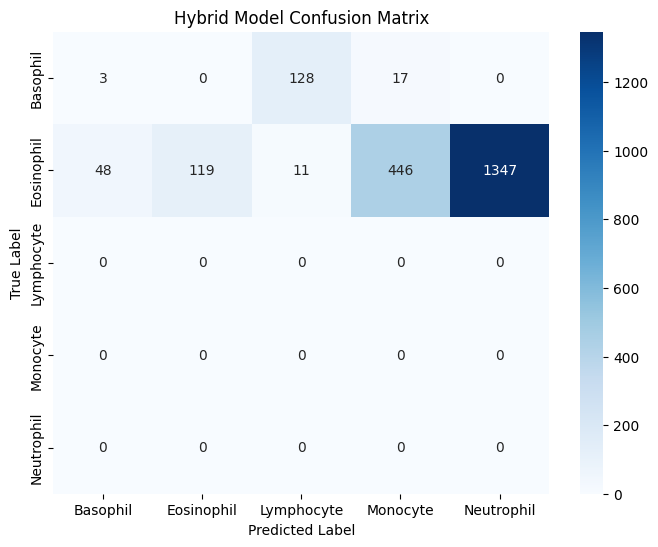

In [ ]:
# Load best saved fine-tuned model (Optional, we already loaded it in the training loop abstraction)
best_hybrid_model = hybrid_model
best_hybrid_model.load_state_dict(torch.load("best_hybrid_model_ft.pth"))

best_test_loss, best_test_acc, y_pred, y_true = evaluate_model(best_hybrid_model, test_loader)
print("Best Hybrid Test Loss:", best_test_loss)
print("Best Hybrid Test Accuracy:", best_test_acc)

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Hybrid Model Confusion Matrix")
plt.show()

# ==========================================


In [ ]:
# 8. Plotting Training History
# ==========================================
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_hybrid['accuracy'], label='Train Accuracy')
plt.plot(history_hybrid['val_accuracy'], label='Validation Accuracy')
plt.title('Hybrid Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_hybrid['loss'], label='Train Loss')
plt.plot(history_hybrid['val_loss'], label='Validation Loss')
plt.title('Hybrid Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()



In [ ]:
# Fine-tuning plot
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_hybrid_ft['accuracy'], label='Fine-tune Train Accuracy')
plt.plot(history_hybrid_ft['val_accuracy'], label='Fine-tune Validation Accuracy')
plt.title('Hybrid Fine-Tuning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_hybrid_ft['loss'], label='Fine-tune Train Loss')
plt.plot(history_hybrid_ft['val_loss'], label='Fine-tune Validation Loss')
plt.title('Hybrid Fine-Tuning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()



In [ ]:
# Sample predictions visualization
plt.figure(figsize=(12, 12))
data_iter = iter(test_loader)
images, labels = next(data_iter)
best_hybrid_model.eval()

with torch.no_grad():
    outputs = best_hybrid_model(images.to(device))
    _, preds = torch.max(outputs, 1)

for i in range(min(9, len(images))):
    ax = plt.subplot(3, 3, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[preds[i]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

# ==========================================


In [ ]:
# 9. Feature Extraction Logic 


In [ ]:
# (Matching the dangling pytorch block at your file end)
# ==========================================


In [ ]:
# To extract purely the features, we bypass our fusion head.


In [ ]:
# The user snippet asked to remove classifier. In our HybridModel, it's `fc2` and before.
class FeatureExtractor(nn.Module):
    def __init__(self, trained_hybrid_model):
        super(FeatureExtractor, self).__init__()
        # Take the feature streams + fusion layer, but stop before final classification
        self.eff = trained_hybrid_model.eff
        self.conv = trained_hybrid_model.conv
        self.fc1 = trained_hybrid_model.fc1
        
    def forward(self, x):
        eff_features = self.eff(x)
        conv_features = self.conv(x)
        fused = torch.cat((eff_features, conv_features), dim=1)
        features = self.fc1(fused)
        return features

extractor = FeatureExtractor(best_hybrid_model).to(device)
extractor.eval()

def extract_features(model, loader, device):
    all_features = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            features = model(images)
            all_features.append(features.cpu().numpy())
            all_labels.append(labels.numpy())

    return np.concatenate(all_features, axis=0), np.concatenate(all_labels, axis=0)



In [ ]:
# (Reusing the dataloaders we initialized at the start without augmentation for raw feature extraction)
raw_train_loader = DataLoader(datasets.ImageFolder(train_path, transform=base_transform), batch_size=32, shuffle=False)

X_train_feat, y_train_feat = extract_features(extractor, raw_train_loader, device)
X_val_feat, y_val_feat = extract_features(extractor, val_loader, device)
X_test_feat, y_test_feat = extract_features(extractor, test_loader, device)

print("Train Features:", X_train_feat.shape)
print("Val Features:", X_val_feat.shape)
print("Test Features:", X_test_feat.shape)

# Stage 2: Leukemia Detection

This section adds the second stage without changing the first WBC classification stage.

Folder structure expected:

```text
D:/RHJ/DataSet/Leukemia/training_data/fold_0/Leukemia
D:/RHJ/DataSet/Leukemia/training_data/fold_0/Normal

D:/RHJ/DataSet/Leukemia/training_data/fold_1/Leukemia
D:/RHJ/DataSet/Leukemia/training_data/fold_1/Normal

D:/RHJ/DataSet/Leukemia/training_data/fold_2/Leukemia
D:/RHJ/DataSet/Leukemia/training_data/fold_2/Normal
```

Stage 1: WBC cell type classification.  
Stage 2: Leukemia / Normal screening.


In [ ]:
# ==========================================
# 10. Stage 2: Leukemia Detection Dataset
# ==========================================

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets
from torch.utils.data import DataLoader
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# Path for the leukemia dataset on your device
leukemia_base_path = "D:/RHJ/DataSet/Leukemia"

# We use the folds inside training_data only:
# fold_0 = Train, fold_1 = Validation, fold_2 = Test
leuk_train_path = os.path.join(leukemia_base_path, "training_data/fold_0")
leuk_val_path   = os.path.join(leukemia_base_path, "training_data/fold_1")
leuk_test_path  = os.path.join(leukemia_base_path, "training_data/fold_2")

print("Leukemia Train Path:", leuk_train_path)
print("Leukemia Val Path:", leuk_val_path)
print("Leukemia Test Path:", leuk_test_path)

print("\nTrain folders:", os.listdir(leuk_train_path))
print("Val folders:", os.listdir(leuk_val_path))
print("Test folders:", os.listdir(leuk_test_path))

# IMPORTANT:
# Inside each fold, folders should be renamed manually:
# all -> Leukemia
# hem -> Normal

leuk_train_dataset = datasets.ImageFolder(leuk_train_path, transform=train_transform)
leuk_val_dataset   = datasets.ImageFolder(leuk_val_path, transform=base_transform)
leuk_test_dataset  = datasets.ImageFolder(leuk_test_path, transform=base_transform)

# num_workers=0 is safer on Windows/Jupyter
leuk_train_loader = DataLoader(leuk_train_dataset, batch_size=32, shuffle=True, num_workers=0)
leuk_val_loader   = DataLoader(leuk_val_dataset, batch_size=32, shuffle=False, num_workers=0)
leuk_test_loader  = DataLoader(leuk_test_dataset, batch_size=32, shuffle=False, num_workers=0)

leuk_class_names = leuk_train_dataset.classes
leukemia_positive_index = leuk_class_names.index("Leukemia") if "Leukemia" in leuk_class_names else 0

print("\nLeukemia classes:", leuk_class_names)
print("Number of leukemia classes:", len(leuk_class_names))
print("Positive class index:", leukemia_positive_index)
print("Train images:", len(leuk_train_dataset))
print("Validation images:", len(leuk_val_dataset))
print("Test images:", len(leuk_test_dataset))


In [ ]:
# ==========================================
# 11. Train Leukemia Detection Model
# ==========================================

leuk_model = HybridModel(num_classes=len(leuk_class_names)).to(device)

criterion_leuk = nn.CrossEntropyLoss()

optimizer_leuk = optim.Adam(
    leuk_model.parameters(),
    lr=1e-3
)

scheduler_leuk = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_leuk,
    mode='min',
    factor=0.5,
    patience=2,
    verbose=True
)

print("--- Starting Leukemia Detection Training ---")

history_leuk = train_eval_loop(
    leuk_model,
    leuk_train_loader,
    leuk_val_loader,
    optimizer_leuk,
    criterion_leuk,
    scheduler_leuk,
    epochs=8,
    save_name="best_leukemia_model.pth"
)


In [ ]:
# ==========================================
# 12. Fine-Tuning Leukemia Model
# ==========================================

print("--- Starting Leukemia Fine-Tuning ---")

unfreeze_last_n_params(leuk_model.eff, n=30)
unfreeze_last_n_params(leuk_model.conv, n=30)

optimizer_leuk_ft = optim.Adam(
    filter(lambda p: p.requires_grad, leuk_model.parameters()),
    lr=1e-5
)

scheduler_leuk_ft = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_leuk_ft,
    mode='min',
    factor=0.5,
    patience=2,
    verbose=True
)

history_leuk_ft = train_eval_loop(
    leuk_model,
    leuk_train_loader,
    leuk_val_loader,
    optimizer_leuk_ft,
    criterion_leuk,
    scheduler_leuk_ft,
    epochs=5,
    save_name="best_leukemia_model_ft.pth"
)


In [ ]:
# ==========================================
# 13. Leukemia Evaluation Function
# ==========================================

def evaluate_leukemia_model(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []
    all_positive_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            total_loss += loss.item() * images.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            if probs.shape[1] == 2:
                all_positive_probs.extend(probs[:, leukemia_positive_index].cpu().numpy())

    avg_loss = total_loss / total
    avg_acc = correct / total

    return (
        avg_loss,
        avg_acc,
        np.array(all_preds),
        np.array(all_labels),
        np.array(all_positive_probs)
    )


In [ ]:
# ==========================================
# 14. Evaluate Best Leukemia Model
# ==========================================

leuk_model.load_state_dict(torch.load("best_leukemia_model_ft.pth", map_location=device))
leuk_model.to(device)
leuk_model.eval()

leuk_test_loss, leuk_test_acc, leuk_y_pred, leuk_y_true, leuk_y_prob = evaluate_leukemia_model(
    leuk_model,
    leuk_test_loader,
    criterion_leuk,
    device
)

print("Leukemia Test Loss:", leuk_test_loss)
print("Leukemia Test Accuracy:", leuk_test_acc)

print("\nClassification Report:")
print(classification_report(
    leuk_y_true,
    leuk_y_pred,
    target_names=leuk_class_names
))

acc = accuracy_score(leuk_y_true, leuk_y_pred)
precision = precision_score(leuk_y_true, leuk_y_pred, pos_label=leukemia_positive_index, zero_division=0)
recall = recall_score(leuk_y_true, leuk_y_pred, pos_label=leukemia_positive_index, zero_division=0)
f1 = f1_score(leuk_y_true, leuk_y_pred, pos_label=leukemia_positive_index, zero_division=0)

print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

if len(leuk_y_prob) > 0:
    leuk_y_true_binary = (leuk_y_true == leukemia_positive_index).astype(int)
    auc = roc_auc_score(leuk_y_true_binary, leuk_y_prob)
    print("ROC-AUC:", auc)


In [ ]:
# ==========================================
# 15. Leukemia Confusion Matrix
# ==========================================

leuk_cm = confusion_matrix(leuk_y_true, leuk_y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    leuk_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=leuk_class_names,
    yticklabels=leuk_class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Leukemia Detection Confusion Matrix")
plt.show()


In [ ]:
# ==========================================
# 16. ROC Curve
# ==========================================

if len(leuk_y_prob) > 0:
    leuk_y_true_binary = (leuk_y_true == leukemia_positive_index).astype(int)
    fpr, tpr, thresholds = roc_curve(leuk_y_true_binary, leuk_y_prob)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Leukemia Detection ROC Curve")
    plt.legend()
    plt.show()


In [ ]:
# ==========================================
# 17. Plot Leukemia Training History
# ==========================================

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_leuk['accuracy'], label='Train Accuracy')
plt.plot(history_leuk['val_accuracy'], label='Validation Accuracy')
plt.title('Leukemia Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_leuk['loss'], label='Train Loss')
plt.plot(history_leuk['val_loss'], label='Validation Loss')
plt.title('Leukemia Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# ==========================================
# 18. Plot Leukemia Fine-Tuning History
# ==========================================

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_leuk_ft['accuracy'], label='Fine-tune Train Accuracy')
plt.plot(history_leuk_ft['val_accuracy'], label='Fine-tune Validation Accuracy')
plt.title('Leukemia Fine-Tuning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_leuk_ft['loss'], label='Fine-tune Train Loss')
plt.plot(history_leuk_ft['val_loss'], label='Fine-tune Validation Loss')
plt.title('Leukemia Fine-Tuning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# ==========================================
# 19. Sample Leukemia Predictions
# ==========================================

plt.figure(figsize=(12, 12))

data_iter = iter(leuk_test_loader)
images, labels = next(data_iter)

leuk_model.eval()

with torch.no_grad():
    outputs = leuk_model(images.to(device))
    _, preds = torch.max(outputs, 1)

for i in range(min(9, len(images))):
    ax = plt.subplot(3, 3, i + 1)
    img = images[i].permute(1, 2, 0).numpy()

    true_label = leuk_class_names[labels[i]]
    pred_label = leuk_class_names[preds[i]]

    plt.imshow(img)
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# ==========================================
# 20. Two-Stage Final Prediction
# Stage 1: WBC Cell Type
# Stage 2: Leukemia / Normal
# ==========================================

# Make sure the best WBC model is available
best_hybrid_model = hybrid_model
try:
    best_hybrid_model.load_state_dict(torch.load("best_hybrid_model_ft.pth", map_location=device))
except FileNotFoundError:
    print("best_hybrid_model_ft.pth not found. Using the current hybrid_model weights.")

best_hybrid_model.to(device)
leuk_model.to(device)

def predict_two_stage(image_tensor):
    best_hybrid_model.eval()
    leuk_model.eval()

    image_tensor = image_tensor.to(device).unsqueeze(0)

    with torch.no_grad():
        # Stage 1: WBC type
        cell_outputs = best_hybrid_model(image_tensor)
        cell_probs = torch.softmax(cell_outputs, dim=1)
        _, cell_pred = torch.max(cell_outputs, 1)

        # Stage 2: Leukemia detection
        leuk_outputs = leuk_model(image_tensor)
        leuk_probs = torch.softmax(leuk_outputs, dim=1)
        _, leuk_pred = torch.max(leuk_outputs, 1)

    cell_type = class_names[cell_pred.item()]
    cell_confidence = cell_probs[0][cell_pred.item()].item()

    leukemia_result = leuk_class_names[leuk_pred.item()]
    leukemia_confidence = leuk_probs[0][leuk_pred.item()].item()

    return cell_type, cell_confidence, leukemia_result, leukemia_confidence


In [ ]:
# ==========================================
# 21. Test Two-Stage Prediction on One WBC Image
# ==========================================

sample_images, sample_labels = next(iter(test_loader))
sample_img = sample_images[0]

cell_type, cell_confidence, leukemia_result, leukemia_confidence = predict_two_stage(sample_img)

print("Final Two-Stage Result")
print("----------------------")
print("Cell Type:", cell_type)
print("Cell Type Confidence:", round(cell_confidence * 100, 2), "%")
print("Leukemia Screening:", leukemia_result)
print("Leukemia Confidence:", round(leukemia_confidence * 100, 2), "%")
print("Note: This result is a screening indication, not a confirmed leukemia diagnosis.")


In [ ]:
# ==========================================
# 22. Visualize Final Two-Stage Prediction
# ==========================================

plt.figure(figsize=(5, 5))
plt.imshow(sample_img.permute(1, 2, 0).numpy())
plt.axis("off")
plt.title(
    f"Cell Type: {cell_type} ({cell_confidence*100:.2f}%)\n"
    f"Leukemia Screening: {leukemia_result} ({leukemia_confidence*100:.2f}%)"
)
plt.show()
